<a href="https://colab.research.google.com/github/csharp135/adni-image-classification/blob/main/AST_303_Homework_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

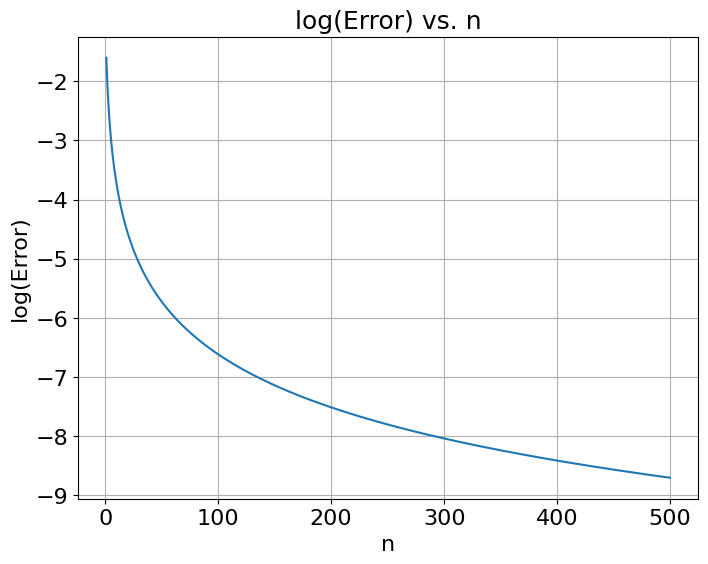

In [1]:
#Question 1a

import math
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

#array of errors of pi approximations
values = np.array([]);

#calculates partial sums for n = 1 to 500 and adds their errors to the array
for n in range(1, 501):
    total = sum((((-1)**(i-1))*4)/((2*i)*((2*i)+1)*((2*i)+2)) for i in range(1, n+1))
    pi_approx = 3 + total
    values = np.append(values, pi_approx - math.pi)

#takes the log of the error values
log_values = np.log10(np.abs(values))

plt.figure(figsize=(8,6))
plt.plot(np.arange(1, 501), log_values)
plt.xlabel('n', fontsize = 16)
plt.ylabel('log(Error)', fontsize = 16)
plt.title('log(Error) vs. n', fontsize = 18)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.grid()

plt.show()

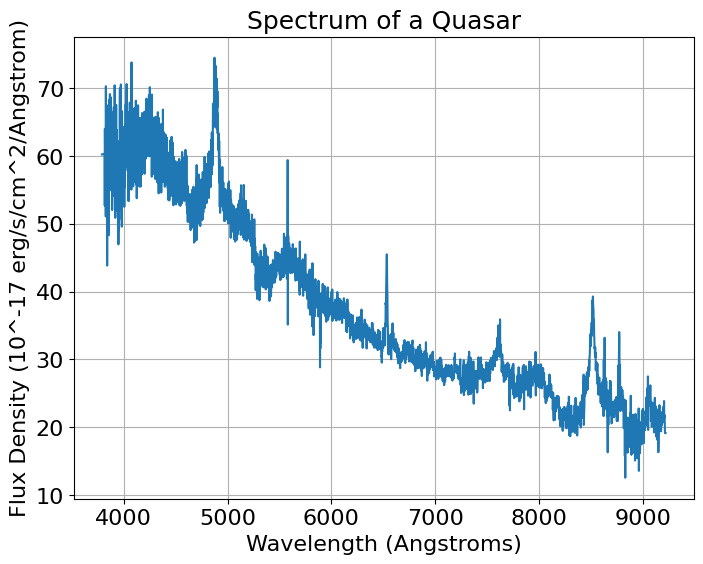

In [4]:
#Question 1b

import numpy as np
import matplotlib.pyplot as plt

#reads the columns of the data file into two arrays
wavelength_data = np.loadtxt('/content/SDSS_quasar.dat', usecols = 0, delimiter = None)
flux_density_data = np.loadtxt('/content/SDSS_quasar.dat', usecols = 1, delimiter = None)

#retrieves the sorted indices for wavelength_data and applies them to both arrays
indices = np.argsort(wavelength_data)
wavelength_sorted = wavelength_data[indices]
flux_density_sorted = flux_density_data[indices]

plt.figure(figsize=(8,6))
plt.plot(wavelength_sorted, flux_density_sorted)
plt.xlabel('Wavelength (Angstroms)', fontsize = 16)
plt.ylabel('Flux Density (10^-17 erg/s/cm^2/Angstrom)', fontsize = 16)
plt.title('Spectrum of a Quasar', fontsize = 18)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.grid()

plt.show()

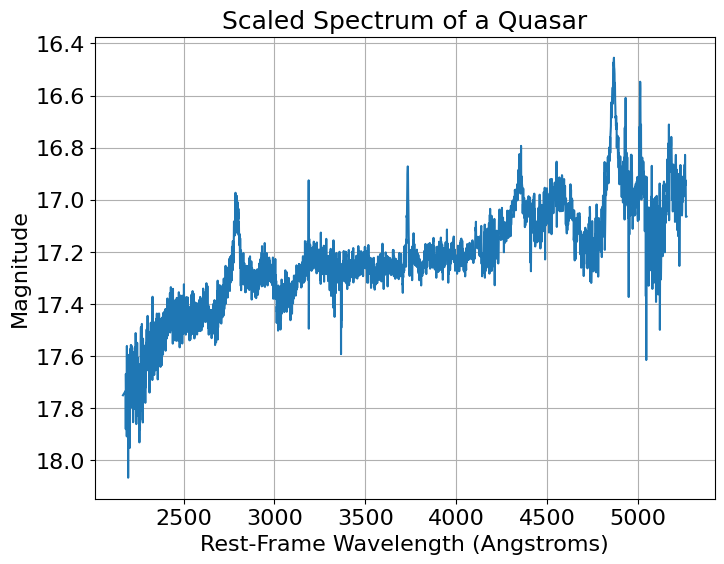

In [5]:
#Question 1c

import numpy as np
import matplotlib.pyplot as plt

#speed of light in A/s units
c = 3.0 * 10**18

#scaled wavelength array
scaled_wavelengths = wavelength_sorted/1.75

#multiply by 10^-17 to get normal cgs units and convert to flux density per frequency
f_lambda = flux_density_sorted * 1e-17
f_nu = np.multiply(f_lambda, wavelength_sorted**2) / c

#filters out f_nu values less than or equal to zero to prevent a log error, then calculates magnitude
good = f_nu > 0
mag = -48.60 - 2.5*np.log10(f_nu[good])

plt.figure(figsize=(8,6))
plt.plot(scaled_wavelengths[good], mag)
plt.xlabel('Rest-Frame Wavelength (Angstroms)', fontsize = 16)
plt.ylabel('Magnitude', fontsize = 16)
plt.title('Scaled Spectrum of a Quasar', fontsize = 18)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.gca().invert_yaxis()
plt.grid()

plt.show()

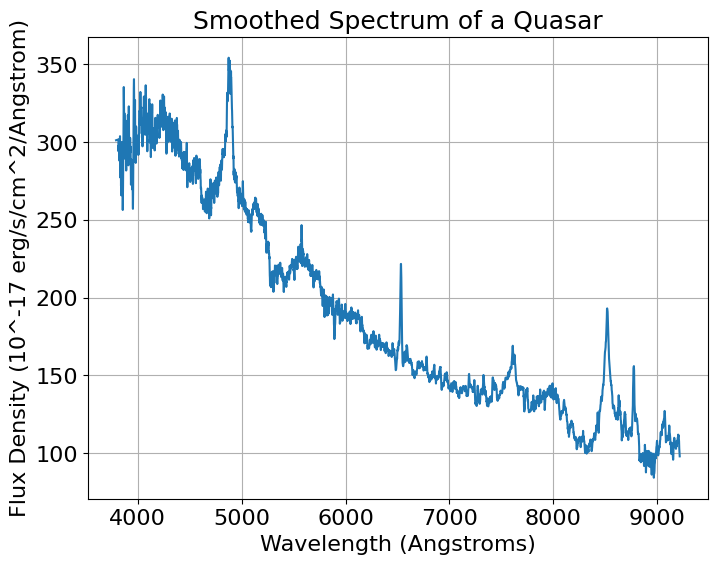

In [6]:
#Question 1d

import numpy as np
import matplotlib.pyplot as plt

#convolves pixels not near the edges with equal weights, does not convolve the edges
flux_density_smooth = np.convolve(flux_density_sorted, np.ones(5), mode='valid')
wavelength_smooth = wavelength_sorted[2:-2]

plt.figure(figsize=(8,6))
plt.plot(wavelength_smooth, flux_density_smooth)
plt.xlabel('Wavelength (Angstroms)', fontsize = 16)
plt.ylabel('Flux Density (10^-17 erg/s/cm^2/Angstrom)', fontsize = 16)
plt.title('Smoothed Spectrum of a Quasar', fontsize = 18)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.grid()

plt.show()

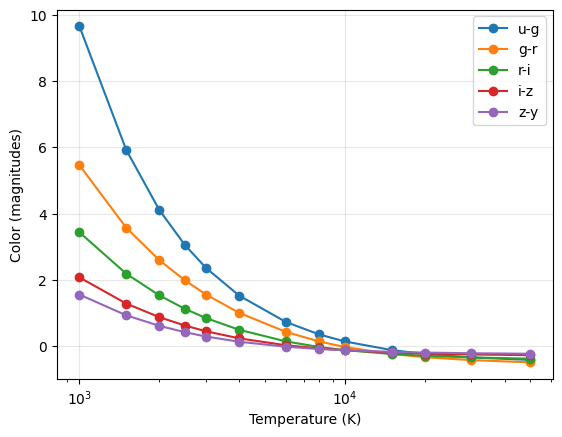

In [7]:
#Question 2a

import numpy as np
import matplotlib.pyplot as plt
import math

#Planck's constant, speed of light, and Boltzmann constant in cgs units
h = 6.626e-27
c = 3e10
k = 1.38e-16

#Creates a dictionary of filter & their wavelength values, pairs of filters to be considered, and an array of temperatures
filters = {"u": (3724, 463), "g": (4807,1485), "r": (6221,1399), "i": (7559,1286), "z": (8680,1040), "y":(9753,862)}
pairs  = [("u","g"), ("g","r"), ("r","i"), ("i","z"), ("z","y")]
temps = np.array([1000,1500,2000,2500,3000,4000,6000,8000,1e4,1.5e4,2e4,3e4,5e4])

#function that calculates magnitude
def mag(T, band, bins = 2000):
    #retrieves values for central wavelength and width
    lambda0, dlambda = filters[band]

    #gives bounds for each of the summation bins
    bin_bounds = np.linspace(lambda0 - (dlambda/2), lambda0 + (dlambda/2), bins+1)

    #gives the center of each bin in cm
    lam = 0.5*(bin_bounds[1:] + bin_bounds[:-1])*1e-8

    #dlambda/lambda for each bin in cm, and dlambda/lambda = dnu/nu
    dlambda_bin = np.diff(bin_bounds)*1e-8 / lam
    nu = c/lam

    #flux density of a blackbody
    f_nu = (2*h*math.pi*(nu**3))/(c**2)/(np.exp((h*nu)/(k*T))-1)

    #returns magnitude using sum of mean flux densities in the bin over sum of the bins' dlambda/lambda
    return -2.5 * np.log10(np.sum(f_nu * dlambda_bin)/np.sum(dlambda_bin))

#stores the difference in magnitudes for each filter in a color array
colors = np.array([[mag(T,p[0])-mag(T,p[1]) for p in pairs] for T in temps])

for j,p in enumerate(pairs):
    plt.plot(temps, colors[:,j], "o-", label = f"{p[0]}-{p[1]}")
plt.xscale("log")
plt.xlabel("Temperature (K)")
plt.ylabel("Color (magnitudes)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
#Question 2c

import numpy as np
import matplotlib.pyplot as plt
import math

#speed of light in A/s
c = 3e18

#Creates a dictionary of filter & their wavelength values and pairs of filters to be considered
filters = {"u": (3724, 463), "g": (4807,1485), "r": (6221,1399), "i": (7559,1286), "z": (8680,1040), "y":(9753,862)}
pairs  = [("u","g"), ("g","r"), ("r","i"), ("i","z"), ("z","y")]

#reads the columns of the data file into two arrays
lambda_data = np.loadtxt('/content/Astar_spectrum.dat', usecols = 0, delimiter = None)
flambda_data = np.loadtxt('/content/Astar_spectrum.dat', usecols = 1, delimiter = None)

#retrieves the sorted indices for wavelength_data and applies them to both arrays
indices = np.argsort(lambda_data)
lambda_sorted = lambda_data[indices]
flambda_sorted = flambda_data[indices]

#function that calculates magnitude
def mag(band, bins = 4000):
    #retrieves values for central wavelength and width
    lambda0, dlambda = filters[band]

    #gives bounds for each of the summation bins
    bin_bounds = np.linspace(lambda0 - dlambda / 2, lambda0 + dlambda / 2, bins+1)

    #gives the center of each bin in cm
    lam = 0.5*(bin_bounds[1:] + bin_bounds[:-1])

    #dlambda for each bin in cm
    width = np.diff(bin_bounds)

    #interpolates the spectrum f_lambda over the summation bins and converts to normal cgs units
    f_lambda = np.interp(lam, lambda_sorted, flambda_sorted) * 1e-17

    #converts f_lambda to f_nu
    f_nu = lam**2 * f_lambda / c

    #returns magnitude using sum of mean flux densities in the bin over sum of the bins' dlambda/lambda
    weight = width/lam
    mean_fnu = np.sum(f_nu * weight)/np.sum(weight)
    return -2.5 * np.log10(mean_fnu) - 48.6

#stores the difference in magnitudes for each filter in a color array
colors = np.array([mag(p[0])-mag(p[1]) for p in pairs])

for color in colors:
    print(color)

0.6991304977919839
-0.22589177926444393
-0.19219466585929013
-0.13699874369261522
-0.07662684990835089
